# Dự đoán Nghẽn Cổ Chai Phần Cứng PC - Quy trình Huấn luyện

Notebook này xây dựng quy trình huấn luyện mô hình phân loại loại nghẽn cổ chai của máy tính:
1. Nạp và kiểm tra dữ liệu cấu hình phần cứng.
2. Phân tích dữ liệu khám phá (EDA).
3. Phân chia tập dữ liệu huấn luyện và kiểm thử.
4. Huấn luyện mô hình **Random Forest Classifier**.
5. Đánh giá mô hình (Confusion Matrix, Classification Report, Feature Importance).
6. Lưu mô hình bằng `joblib` để triển khai trên Flask API.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

# Set style for plots
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Nạp và kiểm tra dữ liệu

Nạp tập dữ liệu CSV chứa 5,000 mẫu cấu hình phần cứng PC và nhãn phân loại nghẽn cổ chai tương ứng.

In [2]:
dataset_path = 'bottleneck_dataset.csv'
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Không tìm thấy file {dataset_path}. Vui lòng chạy generate.js để tạo dữ liệu.")

df = pd.read_csv(dataset_path)
print(f"Tải tập dữ liệu thành công. Kích thước: {df.shape}")
df.head()

Dataset successfully loaded. Shape: (5000, 13)


,cpu_clock_speed,cpu_single_bench_score,cpu_multi_bench_score,ram_capacity,ram_bus_speed,gpu_vram,gpu_bench_score,gpu_time_spy,gpu_time_spy_extreme,gpu_fire_strike_extreme,resolution_width,resolution_height,bottleneck_type
0,3.2,1807,4066,16,3200,24,5117,17262,9512,13778,1920,1080,1
1,3.2,1991,6076,8,2133,8,2312,8242,4302,6566,1920,1080,0
2,3.2,1991,6076,16,2666,12,2227,7784,3823,5932,3840,2160,0
3,3.4,2275,8036,8,2133,12,5041,17657,9546,14178,2560,1440,3
4,1.6,464,231,16,3200,12,5174,18272,8828,14053,3840,2160,1


## 2. Phân tích Dữ liệu Khám phá (EDA)

Kiểm tra phân phối của các nhãn phân loại:
- `0`: Cân bằng (Balanced - Không nghẽn)
- `1`: Nghẽn CPU (CPU Bottleneck)
- `2`: Nghẽn GPU (GPU Bottleneck)
- `3`: Nghẽn RAM (RAM Bottleneck)

C:\Users\tienc\AppData\Local\Temp\ipykernel_8780\3165296521.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_viz, x='bottleneck_label', order=class_labels.values(), palette="viridis")


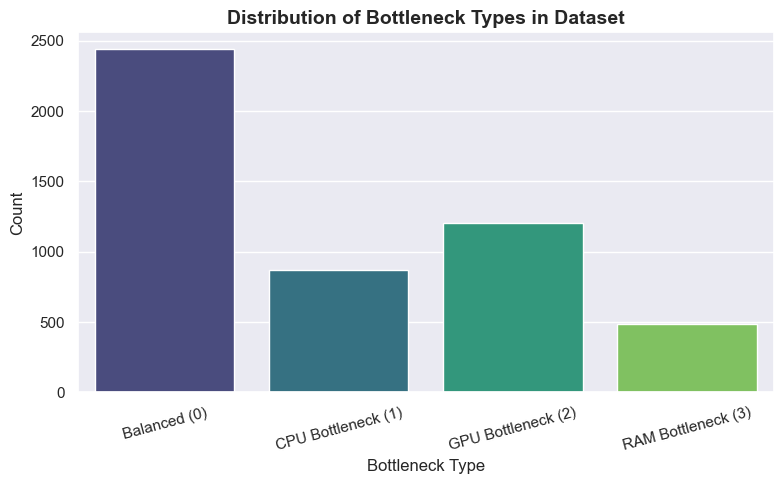

In [3]:
# Target Class Mapping for visualization labels
class_labels = {
    0: "Cân bằng (0)",
    1: "Nghẽn CPU (1)",
    2: "Nghẽn GPU (2)",
    3: "Nghẽn RAM (3)"
}

df_viz = df.copy()
df_viz['bottleneck_label'] = df_viz['bottleneck_type'].map(class_labels)

# Class distributions
plt.figure(figsize=(8, 5))
sns.countplot(data=df_viz, x='bottleneck_label', order=class_labels.values(), palette="viridis")
plt.title("Phân Phối Các Loại Nghẽn Cổ Chai", fontsize=14, fontweight='bold')
plt.xlabel("Loại Nghẽn Cổ Chai", fontsize=12)
plt.ylabel("Số lượng mẫu", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Thống kê Đặc trưng
Bảng mô tả thống kê các thuộc tính số trong tập dữ liệu.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cpu_clock_speed,5000.0,2.969788,0.698353,1.0,2.5,3.06,3.5,4.7
cpu_single_bench_score,5000.0,1905.615800,1109.999074,173.0,1107.0,1611.00,2534.0,5078.0
cpu_multi_bench_score,5000.0,9748.169800,15238.967291,77.0,1433.0,3251.00,12457.0,143003.0
ram_capacity,5000.0,17.251200,9.876174,4.0,8.0,16.00,16.0,64.0
ram_bus_speed,5000.0,3119.492800,880.265273,1600.0,2666.0,3000.00,3200.0,6400.0
gpu_vram,5000.0,9.490400,5.355637,2.0,6.0,8.00,12.0,32.0
gpu_bench_score,5000.0,2674.950600,2532.347191,109.0,1238.0,2090.50,3189.0,15797.0
gpu_time_spy,5000.0,9387.632800,8893.318429,371.0,4432.0,7187.00,11557.0,56900.0
gpu_time_spy_extreme,5000.0,4833.063000,4533.550451,197.0,2262.0,3823.00,6003.0,27065.0
gpu_fire_strike_extreme,5000.0,7492.972600,7058.325091,307.0,3444.0,5821.00,9045.0,42514.0


## 3. Chia dữ liệu Train/Test

Tách các thuộc tính đặc trưng `X` và nhãn `y`, sau đó phân chia dữ liệu theo tỷ lệ 80% Train / 20% Test.

In [5]:
feature_cols = [
    'cpu_clock_speed',
    'cpu_single_bench_score',
    'cpu_multi_bench_score',
    'ram_capacity',
    'ram_bus_speed',
    'gpu_vram',
    'gpu_bench_score',
    'gpu_time_spy',
    'gpu_time_spy_extreme',
    'gpu_fire_strike_extreme',
    'resolution_width',
    'resolution_height'
]
target_col = 'bottleneck_type'

X = df[feature_cols]
y = df[target_col]

# Perform stratified split to maintain target distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")


X_train shape: (4000, 12)
X_test shape: (1000, 12)


## 4. Huấn luyện Mô hình Random Forest

**Random Forest Classifier** là một thuật toán học máy mạnh mẽ thuộc nhóm Ensemble Learning (Học kết hợp):
- **Nguyên lý hoạt động:** Thuật toán xây dựng một quần hợp gồm nhiều cây quyết định ngẫu nhiên trong quá trình huấn luyện và đưa ra dự đoán dựa trên kết quả bỏ phiếu đa số từ các cây.
- **Ưu điểm:** Giảm thiểu hiện tượng quá khớp (overfitting) nhờ sự ngẫu nhiên hóa đặc trưng và tập dữ liệu con, đồng thời cho phép tính toán mức độ quan trọng của các đặc trưng đầu vào dễ dàng.

In [6]:
print("Đang huấn luyện mô hình Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Hoàn thành huấn luyện mô hình.")


Training Random Forest Classifier...
Model training finished.


## 5. Đánh giá Mô hình

Chúng ta đánh giá hiệu năng mô hình qua các chỉ số:
- **Accuracy (Độ chính xác tổng thể):** Tỷ lệ mẫu dự đoán đúng trên tổng số mẫu kiểm thử.
- **Precision (Độ chính xác dự đoán):** Tỷ lệ dự đoán đúng lớp X trên tổng số trường hợp mô hình dự báo lớp X (giúp tránh báo động nhầm).
- **Recall (Độ phủ/Độ nhạy):** Tỷ lệ phát hiện đúng lớp X trên tổng số mẫu thực tế thuộc lớp X (giúp tránh bỏ sót các ca nghẽn thực tế).
- **F1-Score:** Điểm trung bình điều hòa giữa Precision và Recall, đại diện cho hiệu suất tổng hòa khi hai chỉ số trên chênh lệch.

In [7]:
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Độ chính xác trên tập Test: {accuracy * 100:.2f}%\n")

target_names = [class_labels[i] for i in sorted(y.unique())]
print("Báo cáo kết quả phân loại (Classification Report):")
print(classification_report(y_test, y_pred, target_names=target_names))

Overall Testing Accuracy: 94.60%

Classification Report:
                    precision    recall  f1-score   support

      Balanced (0)       0.93      0.98      0.95       488
CPU Bottleneck (1)       0.95      0.90      0.92       174
GPU Bottleneck (2)       0.97      0.95      0.96       241
RAM Bottleneck (3)       0.99      0.85      0.91        97

          accuracy                           0.95      1000
         macro avg       0.96      0.92      0.94      1000
      weighted avg       0.95      0.95      0.95      1000



### Ma trận Nhầm lẫn (Confusion Matrix)
Trực quan hóa sự nhầm lẫn giữa nhãn dự đoán và thực tế qua bản đồ nhiệt (heatmap).

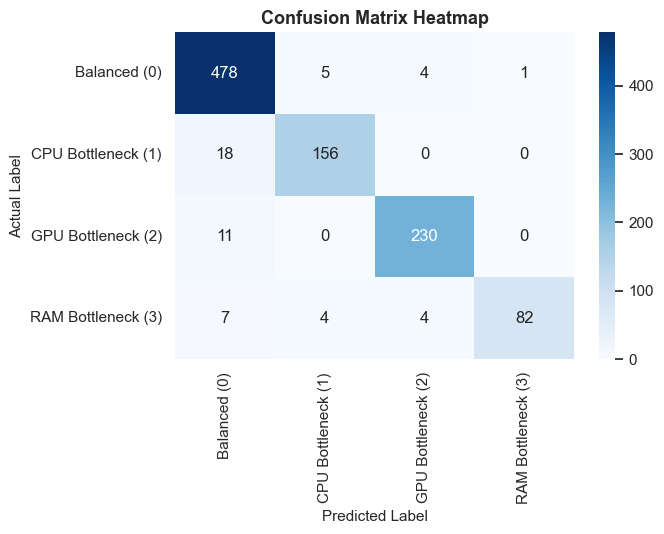

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=target_names, yticklabels=target_names)
plt.title("Bản đồ nhiệt Ma trận Nhầm lẫn", fontsize=13, fontweight='bold')
plt.ylabel("Nhãn Thực tế", fontsize=11)
plt.xlabel("Nhãn Dự đoán", fontsize=11)
plt.tight_layout()
plt.show()

### Độ quan trọng của các Đặc trưng (Feature Importance)
Đánh giá các thuộc tính đầu vào đóng vai trò quan trọng thế nào trong quyết định của mô hình.

C:\Users\tienc\AppData\Local\Temp\ipykernel_8780\1981940812.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices] * 100, y=[feature_cols[i] for i in indices], palette="magma")


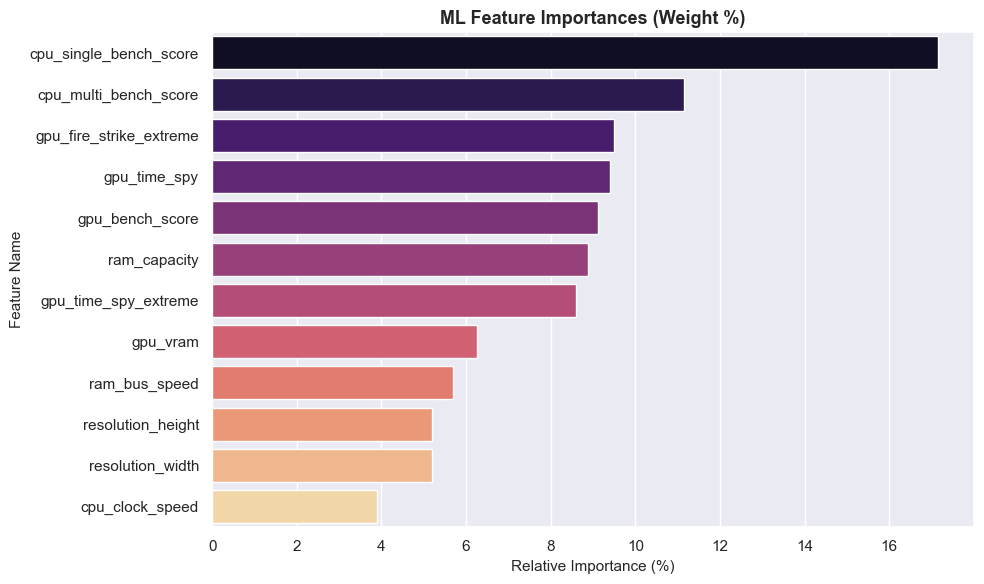

In [9]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Create plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices] * 100, y=[feature_cols[i] for i in indices], palette="magma")
plt.title("Mức Độ Quan Trọng Của Các Đặc Trưng", fontsize=13, fontweight='bold')
plt.xlabel("Tỷ lệ đóng góp (%)", fontsize=11)
plt.ylabel("Thuộc tính đặc trưng", fontsize=11)
plt.tight_layout()
plt.show()

## 6. Xuất Mô hình phục vụ Triển khai Web API

Lưu trữ mô hình đã huấn luyện thành file `.joblib` để server Flask có thể nạp trực tiếp.

In [10]:
model_filename = 'bottleneck_rf_model.joblib'
joblib.dump(rf_model, model_filename)
print(f"Đã lưu mô hình thành công tại: '{os.path.abspath(model_filename)}'")


Successfully saved classifier model to: 'c:\Users\tienc\Documents\DATN\ML_Service\bottleneck_rf_model.joblib'


## 7. Dự đoán Thử nghiệm (Sample Inference)

Chạy dự đoán thử trên 3 cấu hình kiểm thử cụ thể dưới các độ phân giải 1080p, 1440p (2K), và 2160p (4K):
1. **i3 12100F + 16GB RAM + RTX 5090** (CPU yếu / GPU cực mạnh)
2. **Ryzen 7 2700X + 16GB RAM + RTX 5090** (CPU trung bình / GPU cực mạnh)
3. **Ryzen 9 5900X + 32GB RAM + GTX 1060 6GB** (CPU mạnh / GPU yếu)

In [11]:
# Load the saved model
# Tải lại mô hình đã lưu
loaded_model = joblib.load('bottleneck_rf_model.joblib')

# Class definitions mapping
bottleneck_classes = {
    0: "Cân bằng (Không nghẽn)",
    1: "Nghẽn CPU",
    2: "Nghẽn GPU",
    3: "Nghẽn RAM"
}

# Define the 3 test configurations requested with official PassMark & 3DMark scores
test_cases = [
    {
        "name": "Intel Core i3-12100F + 16GB RAM + NVIDIA RTX 5090",
        "cpu_clock_speed": 3.3,
        "cpu_single_bench_score": 3380,       # Official PassMark single-thread avg
        "cpu_multi_bench_score": 14092,       # Official PassMark CPU Mark avg
        "ram_capacity": 16,
        "ram_bus_speed": 3200,
        "gpu_vram": 32,
        "gpu_bench_score": 19845,             # Estimated RTX 5090 Steel Nomad score
        "gpu_time_spy": 30619,
        "gpu_time_spy_extreme": 26600,
        "gpu_fire_strike_extreme": 68039
    },
    {
        "name": "AMD Ryzen 7 2700X + 16GB RAM + NVIDIA RTX 5090",
        "cpu_clock_speed": 3.7,
        "cpu_single_bench_score": 2182,       # Official PassMark single-thread avg
        "cpu_multi_bench_score": 17600,       # Official PassMark CPU Mark avg
        "ram_capacity": 16,
        "ram_bus_speed": 3000,
        "gpu_vram": 32,
        "gpu_bench_score": 19845,             # Estimated RTX 5090 Steel Nomad score
        "gpu_time_spy": 30619,
        "gpu_time_spy_extreme": 26600,
        "gpu_fire_strike_extreme": 68039     # Official 3DMark Fire Strike Extreme score
    },
    {
        "name": "AMD Ryzen 9 5900X + 32GB RAM + NVIDIA GTX 1060 6GB",
        "cpu_clock_speed": 3.7,
        "cpu_single_bench_score": 3480,       # Official PassMark single-thread avg
        "cpu_multi_bench_score": 39100,       # Official PassMark CPU Mark avg
        "ram_capacity": 32,
        "ram_bus_speed": 3600,
        "gpu_vram": 6,
        "gpu_bench_score": 930,               # Official 3DMark Steel Nomad score
        "gpu_time_spy": 4200,                 # Official 3DMark Time Spy score
        "gpu_time_spy_extreme": 1800,         # Official 3DMark Time Spy Extreme score
        "gpu_fire_strike_extreme": 5900       # Official 3DMark Fire Strike Extreme score
    }
]

# Display predictions for each resolution
resolutions = [
    {"label": "1080p Full HD", "width": 1920, "height": 1080},
    {"label": "1440p 2K QHD", "width": 2560, "height": 1440},
    {"label": "2160p 4K UHD", "width": 3840, "height": 2160}
]

for case in test_cases:
    print(f"\n================================================================================")
    print(f"Cấu hình hệ thống: {case['name']}")
    print(f"================================================================================")
    for res in resolutions:
        # Construct feature vector DataFrame matching columns order
        input_data = pd.DataFrame([{
            'cpu_clock_speed': case['cpu_clock_speed'],
            'cpu_single_bench_score': case['cpu_single_bench_score'],
            'cpu_multi_bench_score': case['cpu_multi_bench_score'],
            'ram_capacity': case['ram_capacity'],
            'ram_bus_speed': case['ram_bus_speed'],
            'gpu_vram': case['gpu_vram'],
            'gpu_bench_score': case['gpu_bench_score'],
            'gpu_time_spy': case['gpu_time_spy'],
            'gpu_time_spy_extreme': case['gpu_time_spy_extreme'],
            'gpu_fire_strike_extreme': case['gpu_fire_strike_extreme'],
            'resolution_width': res['width'],
            'resolution_height': res['height']
        }], columns=feature_cols)
        
        pred_val = loaded_model.predict(input_data)[0]
        prob_val = loaded_model.predict_proba(input_data)[0][pred_val]
        
        print(f"Độ phân giải: {res['label']} ({res['width']}x{res['height']})")
        print(f"  -> Kết quả dự đoán: {bottleneck_classes[pred_val]} (Độ tin cậy: {prob_val*100:.1f}%)")



System Configuration: Intel Core i3-12100F + 16GB RAM + NVIDIA RTX 5090
Resolution: 1080p Full HD (1920x1080)
  -> Predicted Bottleneck: CPU Bottleneck (Confidence: 96.0%)
Resolution: 1440p 2K QHD (2560x1440)
  -> Predicted Bottleneck: CPU Bottleneck (Confidence: 83.0%)
Resolution: 2160p 4K UHD (3840x2160)
  -> Predicted Bottleneck: Balanced (No Bottleneck) (Confidence: 65.0%)

System Configuration: AMD Ryzen 7 2700X + 16GB RAM + NVIDIA RTX 5090
Resolution: 1080p Full HD (1920x1080)
  -> Predicted Bottleneck: CPU Bottleneck (Confidence: 95.0%)
Resolution: 1440p 2K QHD (2560x1440)
  -> Predicted Bottleneck: CPU Bottleneck (Confidence: 87.0%)
Resolution: 2160p 4K UHD (3840x2160)
  -> Predicted Bottleneck: CPU Bottleneck (Confidence: 44.0%)

System Configuration: AMD Ryzen 9 5900X + 32GB RAM + NVIDIA GTX 1060 6GB
Resolution: 1080p Full HD (1920x1080)
  -> Predicted Bottleneck: GPU Bottleneck (Confidence: 79.0%)
Resolution: 1440p 2K QHD (2560x1440)
  -> Predicted Bottleneck: GPU Bottlenec